# Assignment 1
## Part A Analyse

### 1.1 config

In [34]:
!pip3 install pydicom

In [35]:
from pathlib import Path
import copy
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import pydicom
from PIL import Image
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, TensorDataset
from torchvision import models
from torchvision.transforms import v2
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix, accuracy_score, recall_score, precision_score, f1_score,
    roc_auc_score, average_precision_score, roc_curve, precision_recall_curve
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")

DATA_ROOT = Path("data/images")
LABEL_FILE = Path("assignment1_labels.csv")
MAPPING_FILE = Path("rsna_to_nih_mapping.csv")
SPLIT_FILE = Path("splits.csv")
print("Device:", DEVICE)

Device: mps


In [36]:
dicom_files = list(DATA_ROOT.rglob("*.dcm"))
print("DICOM files found:", len(dicom_files))
print("Label file found:", LABEL_FILE.exists())
print("Mapping file found:", MAPPING_FILE.exists())
assert len(dicom_files) > 0, "No DICOM files were found."
assert LABEL_FILE.exists(), "The label file was not found."
assert MAPPING_FILE.exists(), "The mapping file was not found."

DICOM files found: 25684
Label file found: True
Mapping file found: True


In [37]:
labels = pd.read_csv(LABEL_FILE)
mapping = pd.read_csv(MAPPING_FILE, dtype={"nih_patient_id": str})

print("Label rows:", len(labels))
print("Unique images:", labels["patientId"].nunique())
print(labels.groupby("patientId").size().value_counts().sort_index())

Label rows: 28989
Unique images: 25684
1    22506
2     3062
3      105
4       11
Name: count, dtype: int64


In [38]:
assert (labels.groupby("patientId")["Target"].nunique() == 1).all()

images = labels.groupby("patientId").agg(target=("Target", "max"), n_boxes=("x", "count")).reset_index()
images = images.rename(columns={"patientId": "image_id"})
images.head()

,image_id,target,n_boxes
0,1.2.276.0.7230010.3.1.4.8323329.10001.15178743...,0,0
1,1.2.276.0.7230010.3.1.4.8323329.10002.15178743...,0,0
2,1.2.276.0.7230010.3.1.4.8323329.10004.15178743...,0,0
3,1.2.276.0.7230010.3.1.4.8323329.10005.15178743...,0,0
4,1.2.276.0.7230010.3.1.4.8323329.10006.15178743...,0,0


In [39]:
print("Unique studies (examinations):", labels["StudyInstanceUID"].nunique())
print("Unique series:", labels["SeriesInstanceUID"].nunique())
print("Unique images (SOP):", labels["SOPInstanceUID"].nunique())

files_on_disk = set(path.stem for path in dicom_files)
print("Labelled but missing on disk:", len(set(images["image_id"]) - files_on_disk))
print("On disk but unlabelled:", len(files_on_disk - set(images["image_id"])))

images = images.merge(mapping, left_on="image_id", right_on="patientId", how="left").drop(columns="patientId")
assert images["nih_patient_id"].notna().all()

images_per_patient = images.groupby("nih_patient_id").size()
print("Unique source patients:", images["nih_patient_id"].nunique())
print(images_per_patient.describe())
print("Patients with 1 image:", (images_per_patient == 1).sum())
print("Patients with >1 image:", (images_per_patient > 1).sum())

Unique studies (examinations): 25684
Unique series: 25684
Unique images (SOP): 25684
Labelled but missing on disk: 0
On disk but unlabelled: 0
Unique source patients: 11171
count    11171.000000
mean         2.299167
std          3.307870
min          1.000000
25%          1.000000
50%          1.000000
75%          2.000000
max         63.000000
dtype: float64
Patients with 1 image: 6973
Patients with >1 image: 4198


In [40]:
class_counts = images["target"].value_counts().sort_index()
class_table = pd.DataFrame({"count": class_counts, "proportion": class_counts / len(images)})
class_table.index = ["No pneumonia", "Pneumonia"]
display(class_table.round(4))

patient_labels = images.groupby("nih_patient_id")["target"].agg(["sum", "count"])
print("All-negative patients:", (patient_labels["sum"] == 0).sum())
print("Mixed patients:", ((patient_labels["sum"] > 0) & (patient_labels["sum"] < patient_labels["count"])).sum())
print("All-positive patients:", (patient_labels["sum"] == patient_labels["count"]).sum())

,count,proportion
No pneumonia,20025,0.7797
Pneumonia,5659,0.2203


All-negative patients: 8913
Mixed patients: 1650
All-positive patients: 608


In [41]:
rows = []
for path in dicom_files:
    ds = pydicom.dcmread(path, stop_before_pixels=True)
    rows.append({
        "image_id": ds.SOPInstanceUID,
        "path": str(path),
        "rows": ds.Rows,
        "columns": ds.Columns,
        "photometric": ds.PhotometricInterpretation,
        "bits_stored": ds.BitsStored,
        "modality": ds.Modality,
        "view": ds.get("ViewPosition"),
        "sex": ds.get("PatientSex"),
        "age": int(ds.PatientAge),
        "pixel_spacing": float(ds.PixelSpacing[0]),
        "transfer_syntax": ds.file_meta.TransferSyntaxUID.name,
    })

headers = pd.DataFrame(rows)
images = images.merge(headers, on="image_id", how="left")
assert images["path"].notna().all()

In [42]:
for column in ["rows", "columns", "photometric", "bits_stored", "modality", "transfer_syntax", "view"]:
    print(column, images[column].value_counts().to_dict())

print(pd.crosstab(images["view"], images["target"], margins=True))
print(pd.crosstab(images["view"], images["target"], normalize="index").round(3))

rows {1024: 25684}
columns {1024: 25684}
photometric {'MONOCHROME2': 25684}
bits_stored {8: 25684}
modality {'CR': 25684}
transfer_syntax {'JPEG Baseline (Process 1)': 25684}
view {'PA': 13979, 'AP': 11705}
target      0     1    All
view                      
AP       7310  4395  11705
PA      12715  1264  13979
All     20025  5659  25684
target      0      1
view                
AP      0.625  0.375
PA      0.910  0.090


In [43]:
def load_image(path):
    ds = pydicom.dcmread(path)
    image = ds.pixel_array
    if ds.PhotometricInterpretation == "MONOCHROME1":
        image = image.max() - image
    return image


rows = []
for path in images["path"]:
    image = load_image(path)
    rows.append({
        "path": path,
        "height": image.shape[0],
        "width": image.shape[1],
        "pixel_mean": image.mean(),
        "pixel_std": image.std(),
        "frac_black": (image == 0).mean(),
    })

stats = pd.DataFrame(rows)
images = images.merge(stats, on="path", how="left")

same_shape = (images["height"] == images["rows"]) & (images["width"] == images["columns"])
print("Decoded shape matches header:", same_shape.all())
images[["pixel_mean", "pixel_std", "frac_black"]].describe()

Decoded shape matches header: True


,pixel_mean,pixel_std,frac_black
count,25684.000000,25684.000000,25684.000000
mean,124.945081,58.496187,0.025990
std,21.609983,10.867730,0.050010
min,26.417231,18.836551,0.000000
25%,110.426340,51.010788,0.001185
50%,120.302621,59.935902,0.007188
75%,137.162165,67.108744,0.032537
max,229.147834,99.117195,0.710204


In [44]:
boxes = labels.dropna(subset=["x"])
box_area = (boxes["width"] * boxes["height"]).groupby(boxes["patientId"]).sum()
images["box_area"] = images["image_id"].map(box_area).fillna(0)

positives = images[images["target"] == 1]
adult_negatives = images[(images["target"] == 0) & (images["age"] >= 18)]

picked = [
    ("Typical negative (PA)", adult_negatives[adult_negatives["view"] == "PA"].sample(1, random_state=SEED).iloc[0]),
    ("Negative, AP (portable)", adult_negatives[adult_negatives["view"] == "AP"].sample(1, random_state=SEED).iloc[0]),
    ("Typical positive (AP, bilateral)", positives[(positives["view"] == "AP") & (positives["n_boxes"] == 2)].sample(1, random_state=SEED).iloc[0]),
    ("Positive (PA)", positives[positives["view"] == "PA"].sample(1, random_state=SEED).iloc[0]),
    ("Difficult: smallest opacity", positives.nsmallest(1, "box_area").iloc[0]),
    ("Difficult: 4 separate opacities", images[images["n_boxes"] == 4].sample(1, random_state=SEED).iloc[0]),
    ("Unusual: most black padding", images.nlargest(1, "frac_black").iloc[0]),
    ("Unusual: lowest contrast", images.nsmallest(1, "pixel_std").iloc[0]),
]

rows = []
for name, row in picked:
    rows.append({
        "example": name,
        "target": row["target"],
        "n_boxes": row["n_boxes"],
        "view": row["view"],
        "sex": row["sex"],
        "age": row["age"],
        "size": f"{row['rows']}x{row['columns']}",
        "photometric": row["photometric"],
    })
pd.DataFrame(rows)

,example,target,n_boxes,view,sex,age,size,photometric
0,Typical negative (PA),0,0,PA,F,51,1024x1024,MONOCHROME2
1,"Negative, AP (portable)",0,0,AP,M,38,1024x1024,MONOCHROME2
2,"Typical positive (AP, bilateral)",1,2,AP,F,36,1024x1024,MONOCHROME2
3,Positive (PA),1,2,PA,M,70,1024x1024,MONOCHROME2
4,Difficult: smallest opacity,1,1,AP,F,61,1024x1024,MONOCHROME2
5,Difficult: 4 separate opacities,1,4,AP,M,43,1024x1024,MONOCHROME2
6,Unusual: most black padding,0,0,AP,F,4,1024x1024,MONOCHROME2
7,Unusual: lowest contrast,0,0,AP,M,47,1024x1024,MONOCHROME2


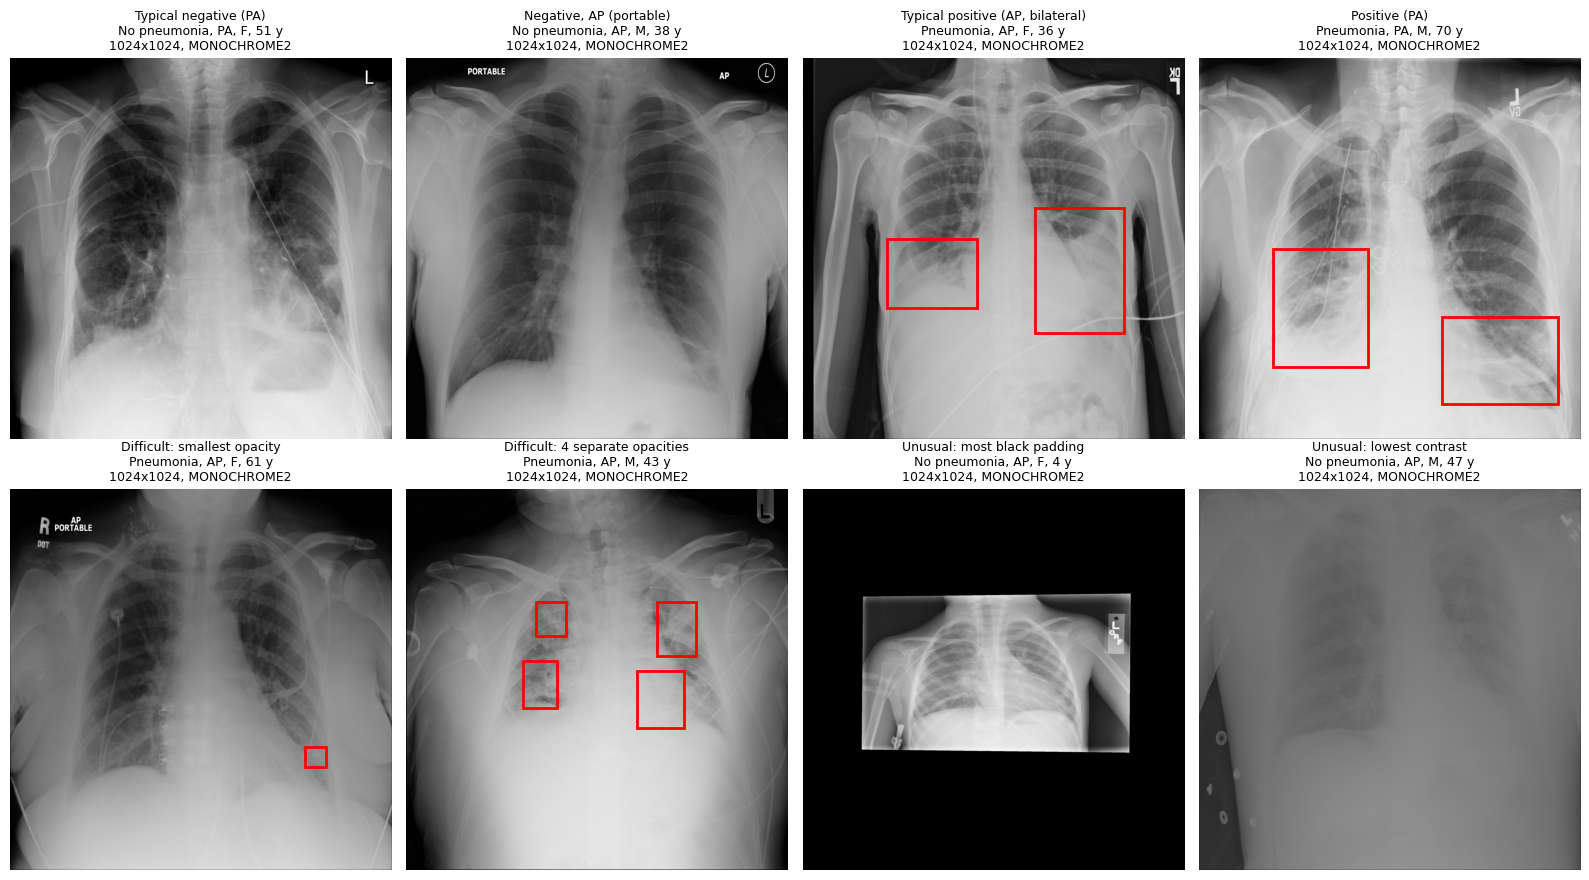

In [45]:
fig, axes = plt.subplots(2, 4, figsize=(16, 9))
for ax, (name, row) in zip(axes.flat, picked):
    ax.imshow(load_image(row["path"]), cmap="gray", vmin=0, vmax=255)
    for _, box in boxes[boxes["patientId"] == row["image_id"]].iterrows():
        ax.add_patch(Rectangle((box["x"], box["y"]), box["width"], box["height"], fill=False, edgecolor="red", linewidth=2))
    label = "Pneumonia" if row["target"] == 1 else "No pneumonia"
    ax.set_title(f"{name}\n{label}, {row['view']}, {row['sex']}, {row['age']} y\n{row['rows']}x{row['columns']}, {row['photometric']}", fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()

## Part B Data Split

In [46]:
patients = images.groupby("nih_patient_id")["target"].agg(["count", "sum"]).reset_index()
patients.columns = ["nih_patient_id", "n_images", "n_pos"]

share_group = pd.cut(patients["n_pos"] / patients["n_images"], bins=[-0.01, 0, 0.5, 1], labels=["none", "some", "most"])
size_group = pd.cut(patients["n_images"], bins=[0, 1, 3, 10, 1000], labels=["1", "2-3", "4-10", "11+"])
patients["stratum"] = share_group.astype(str) + " | " + size_group.astype(str)
patients["stratum"].value_counts()

stratum
none | 1       6467
none | 2-3     1997
some | 4-10     634
most | 1        506
some | 2-3      498
none | 4-10     438
some | 11+      173
most | 4-10     169
most | 2-3      157
most | 11+      121
none | 11+       11
Name: count, dtype: int64

In [47]:
dev_patients, test_patients = train_test_split(
    patients, test_size=0.15, stratify=patients["stratum"], random_state=SEED
)
train_patients, val_patients = train_test_split(
    dev_patients, test_size=0.15 / 0.85, stratify=dev_patients["stratum"], random_state=SEED
)

images["split"] = None
images.loc[images["nih_patient_id"].isin(train_patients["nih_patient_id"]), "split"] = "train"
images.loc[images["nih_patient_id"].isin(val_patients["nih_patient_id"]), "split"] = "val"
images.loc[images["nih_patient_id"].isin(test_patients["nih_patient_id"]), "split"] = "test"

In [48]:
train_ids = set(images.loc[images["split"] == "train", "nih_patient_id"])
val_ids = set(images.loc[images["split"] == "val", "nih_patient_id"])
test_ids = set(images.loc[images["split"] == "test", "nih_patient_id"])

assert len(train_ids & val_ids) == 0, "Patients shared by train and val"
assert len(train_ids & test_ids) == 0, "Patients shared by train and test"
assert len(val_ids & test_ids) == 0, "Patients shared by val and test"
assert len(train_ids | val_ids | test_ids) == images["nih_patient_id"].nunique(), "Some patients were not assigned"
assert images["split"].notna().all(), "Some images were not assigned"

print("Patients in train / val / test:", len(train_ids), len(val_ids), len(test_ids))
print("No patient appears in more than one split.")

Patients in train / val / test: 7819 1676 1676
No patient appears in more than one split.


In [49]:
rows = []
for split in ["train", "val", "test"]:
    part = images[images["split"] == split]
    rows.append({
        "split": split,
        "patients": part["nih_patient_id"].nunique(),
        "images": len(part),
        "image_share": len(part) / len(images),
        "positives": part["target"].sum(),
        "positive_rate": part["target"].mean(),
        "ap_rate": (part["view"] == "AP").mean(),
    })
rows.append({
    "split": "total",
    "patients": images["nih_patient_id"].nunique(),
    "images": len(images),
    "image_share": 1.0,
    "positives": images["target"].sum(),
    "positive_rate": images["target"].mean(),
    "ap_rate": (images["view"] == "AP").mean(),
})
split_report = pd.DataFrame(rows).set_index("split")
split_report.round(4)

,patients,images,image_share,positives,positive_rate,ap_rate
split,,,,,,
train,7819,18007,0.7011,3943,0.2190,0.4493
val,1676,3870,0.1507,866,0.2238,0.4736
test,1676,3807,0.1482,850,0.2233,0.4681
total,11171,25684,1.0000,5659,0.2203,0.4557


In [50]:
if not SPLIT_FILE.exists():
    images[["image_id", "nih_patient_id", "path", "target", "view", "split"]].to_csv(SPLIT_FILE, index=False)
    print("Split saved to", SPLIT_FILE)

saved_split = pd.read_csv(SPLIT_FILE)
check = images[["image_id", "split"]].merge(saved_split[["image_id", "split"]], on="image_id", suffixes=("", "_saved"))
assert len(check) == len(images), "The split file does not match the images"
assert (check["split"] == check["split_saved"]).all(), "The split differs from the frozen file"
print("Split matches", SPLIT_FILE)

Split matches splits.csv


In [51]:
images["device"] = images["pixel_spacing"].round(3).astype(str)
print(pd.crosstab(images["device"], images["target"], normalize="index").round(3))

train_part = images[images["split"] == "train"]
val_part = images[images["split"] == "val"]
for features in [["view"], ["device"], ["view", "device"]]:
    X_meta_train = pd.get_dummies(train_part[features])
    X_meta_val = pd.get_dummies(val_part[features]).reindex(columns=X_meta_train.columns, fill_value=0)
    classifier = LogisticRegression(max_iter=1000).fit(X_meta_train, train_part["target"])
    auc = roc_auc_score(val_part["target"], classifier.predict_proba(X_meta_val)[:, 1])
    print(features, "val ROC-AUC:", round(auc, 3))

target      0      1
device              
0.115   0.750  0.250
0.139   0.689  0.311
0.143   0.918  0.082
0.168   0.682  0.318
0.171   0.734  0.266
0.194   0.930  0.070
0.199   0.333  0.667
['view'] val ROC-AUC: 0.704
['device'] val ROC-AUC: 0.664
['view', 'device'] val ROC-AUC: 0.709


## Part C

In [52]:
IMG_SIZE = 256
CACHE_FILE = Path(f"cache/images_{IMG_SIZE}.npy")

splits = pd.read_csv(SPLIT_FILE, dtype={"nih_patient_id": str})
splits["cache_index"] = np.arange(len(splits))


def dicom_to_array(path):
    image = Image.fromarray(load_image(path))
    image = image.resize((IMG_SIZE, IMG_SIZE), Image.Resampling.BILINEAR)
    return np.asarray(image, dtype=np.uint8)


if not CACHE_FILE.exists():
    CACHE_FILE.parent.mkdir(exist_ok=True)
    cache = np.stack([dicom_to_array(path) for path in splits["path"]])
    np.save(CACHE_FILE, cache)

cache = np.load(CACHE_FILE)
assert cache.shape == (len(splits), IMG_SIZE, IMG_SIZE)
assert (cache[::500].max(axis=(1, 2)) > 0).all(), "The cache contains empty images"
print("Cache:", cache.shape, cache.dtype, round(cache.nbytes / 1e9, 2), "GB")

Cache: (25684, 256, 256) uint8 1.68 GB


In [53]:
train_rows = np.where(splits["split"] == "train")[0]
sample_rows = np.random.default_rng(0).choice(train_rows, 2000, replace=False)
sample = cache[sample_rows] / 255.0
print("Train pixel mean:", round(sample.mean(), 3), "std:", round(sample.std(), 3))

Train pixel mean: 0.49 std: 0.246


In [54]:
IMAGENET_GRAY_MEAN = 0.449
IMAGENET_GRAY_STD = 0.226

train_transform = v2.Compose([
    v2.ColorJitter(brightness=0.2, contrast=0.2),
    v2.RandomAffine(degrees=10, translate=(0.05, 0.05), scale=(0.9, 1.1), fill=0),
])


class ChestXrayDataset(Dataset):
    def __init__(self, table, image_array, transform=None):
        self.table = table.reset_index(drop=True)
        self.image_array = image_array
        self.transform = transform

    def __len__(self):
        return len(self.table)

    def __getitem__(self, index):
        row = self.table.iloc[index]
        image = self.image_array[row.cache_index].astype(np.float32) / 255.0
        image = torch.from_numpy(image).unsqueeze(0)
        if self.transform is not None:
            image = self.transform(image)
        image = (image - IMAGENET_GRAY_MEAN) / IMAGENET_GRAY_STD
        label = torch.tensor(float(row.target), dtype=torch.float32)
        return image, label, int(row.cache_index)


train_table = splits[splits["split"] == "train"]
validation_table = splits[splits["split"] == "val"]

train_dataset = ChestXrayDataset(train_table, cache, transform=train_transform)
validation_dataset = ChestXrayDataset(validation_table, cache)
validation_loader = DataLoader(validation_dataset, batch_size=128, shuffle=False, num_workers=0)

image, label, index = train_dataset[0]
print("Train images:", len(train_dataset), "| validation images:", len(validation_dataset))
print("Image tensor:", tuple(image.shape), image.dtype, "| range:", round(float(image.min()), 2), "to", round(float(image.max()), 2))

Train images: 18007 | validation images: 3870
Image tensor: (1, 256, 256) torch.float32 | range: -1.99 to 2.33


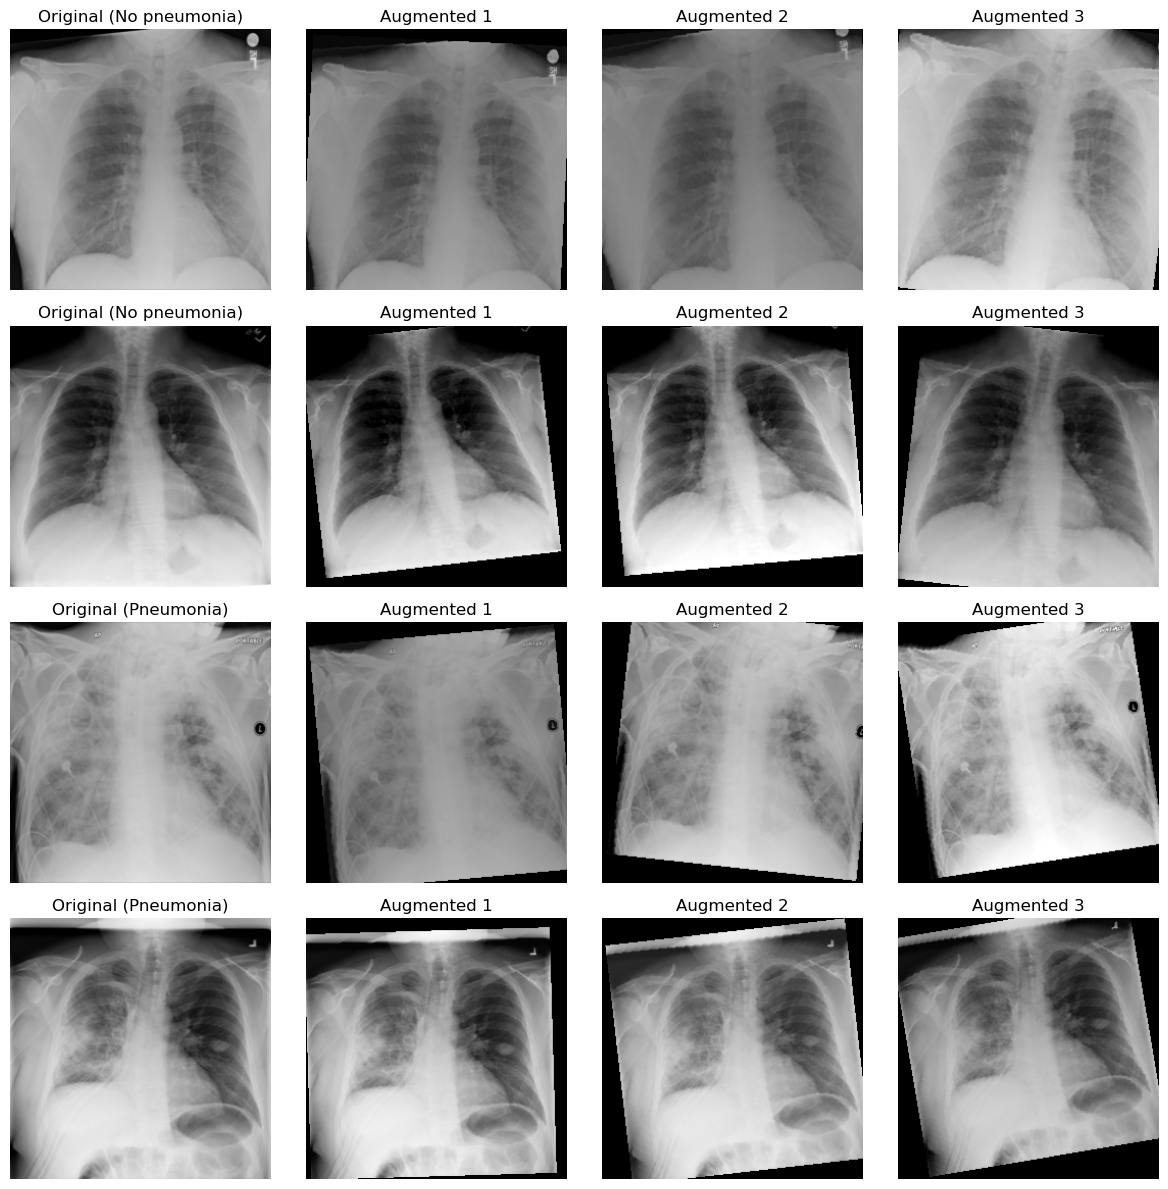

In [ ]:
torch.manual_seed(0)
examples = pd.concat([
    train_table[train_table["target"] == 0].sample(2, random_state=1),
    train_table[train_table["target"] == 1].sample(2, random_state=1),
])

fig, axes = plt.subplots(4, 4, figsize=(12, 12))
for row_number, (_, row) in enumerate(examples.iterrows()):
    original = torch.from_numpy(cache[row["cache_index"]].astype(np.float32) / 255.0).unsqueeze(0)
    label = "Pneumonia" if row["target"] == 1 else "No pneumonia"
    axes[row_number, 0].imshow(original[0], cmap="gray", vmin=0, vmax=1)
    axes[row_number, 0].set_title(f"Original ({label})")
    for column_number in range(1, 4):
        augmented = train_transform(original)
        axes[row_number, column_number].imshow(augmented[0], cmap="gray", vmin=0, vmax=1)
        axes[row_number, column_number].set_title(f"Augmented {column_number}")
for ax in axes.flat:
    ax.axis("off")
plt.tight_layout()
plt.show()

In [56]:
train_boxes = boxes[boxes["patientId"].isin(train_table["image_id"])]

rng = np.random.default_rng(0)
grid_u, grid_v = np.meshgrid(np.linspace(0, 1, 15), np.linspace(0, 1, 15))
kept = []
for _, box in train_boxes.iterrows():
    points_x = box["x"] + grid_u.ravel() * box["width"] - 512
    points_y = box["y"] + grid_v.ravel() * box["height"] - 512
    for _ in range(10):
        angle = np.deg2rad(rng.uniform(-10, 10))
        zoom = rng.uniform(0.9, 1.1)
        shift_x, shift_y = rng.uniform(-0.05, 0.05, size=2) * 1024
        new_x = zoom * (np.cos(angle) * points_x - np.sin(angle) * points_y) + shift_x + 512
        new_y = zoom * (np.sin(angle) * points_x + np.cos(angle) * points_y) + shift_y + 512
        inside = (new_x >= 0) & (new_x < 1024) & (new_y >= 0) & (new_y < 1024)
        kept.append(inside.mean())

kept = np.array(kept)
print("Mean share of opacity kept in frame:", round(kept.mean(), 4))
print("Augmentations keeping 100%:", round((kept == 1).mean(), 4))
print("Augmentations keeping less than 90%:", round((kept < 0.9).mean(), 4))
print("Worst case:", round(kept.min(), 2))

Mean share of opacity kept in frame: 0.9989
Augmentations keeping 100%: 0.9815
Augmentations keeping less than 90%: 0.0034
Worst case: 0.63


In [57]:
n_positive = int(train_table["target"].sum())
n_negative = len(train_table) - n_positive
POS_WEIGHT = n_negative / n_positive
print(f"Training cases: {n_negative} negative, {n_positive} positive")
print("Positive-class weight:", round(POS_WEIGHT, 3))

criterion_plain = nn.BCEWithLogitsLoss()
criterion_weighted = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([POS_WEIGHT]))
logit = torch.tensor([0.0])
for label_value in [1.0, 0.0]:
    target = torch.tensor([label_value])
    plain_loss = criterion_plain(logit, target).item()
    weighted_loss = criterion_weighted(logit, target).item()
    print(f"Label {label_value:.0f}: plain loss = {plain_loss:.3f}, weighted loss = {weighted_loss:.3f}")

Training cases: 14064 negative, 3943 positive
Positive-class weight: 3.567
Label 1: plain loss = 0.693, weighted loss = 2.472
Label 0: plain loss = 0.693, weighted loss = 0.693


## Part D Implementing Baseline

In [58]:
def metric_row(name, y_true, y_prob, threshold=0.5):
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)
    y_pred = (y_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    sensitivity = recall_score(y_true, y_pred, zero_division=0)
    specificity = tn / max(tn + fp, 1)
    return {
        "Model": name,
        "ROC-AUC": roc_auc_score(y_true, y_prob),
        "Average precision": average_precision_score(y_true, y_prob),
        "Accuracy": accuracy_score(y_true, y_pred),
        "Balanced accuracy": (sensitivity + specificity) / 2,
        "Sensitivity": sensitivity,
        "Specificity": specificity,
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
    }


def threshold_table(y_true, y_prob):
    rows = []
    for threshold in np.linspace(0.01, 0.99, 99):
        y_pred = (y_prob >= threshold).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
        rows.append({
            "threshold": threshold,
            "sensitivity": tp / max(tp + fn, 1),
            "specificity": tn / max(tn + fp, 1),
        })
    return pd.DataFrame(rows)


def youden_threshold(y_true, y_prob):
    table = threshold_table(y_true, y_prob)
    youden = table["sensitivity"] + table["specificity"] - 1
    return table.loc[youden.idxmax(), "threshold"]


y_train = train_table["target"].to_numpy()
y_val = validation_table["target"].to_numpy()
y_test = splits.loc[splits["split"] == "test", "target"].to_numpy()

train_prevalence = y_train.mean()
print("Training prevalence:", round(train_prevalence, 4), "-> majority class: 0 (no pneumonia)")

trivial = pd.DataFrame([
    metric_row("Majority class (val)", y_val, np.full(len(y_val), train_prevalence)),
    metric_row("Majority class (test)", y_test, np.full(len(y_test), train_prevalence)),
]).set_index("Model")
trivial.round(4)

Training prevalence: 0.219 -> majority class: 0 (no pneumonia)


,ROC-AUC,Average precision,Accuracy,Balanced accuracy,Sensitivity,Specificity,Precision,F1
Model,,,,,,,,
Majority class (val),0.5,0.2238,0.7762,0.5,0.0,1.0,0.0,0.0
Majority class (test),0.5,0.2233,0.7767,0.5,0.0,1.0,0.0,0.0


In [59]:
def image_features(image):
    x = image.astype(np.float32) / 255.0
    features = {"mean": x.mean(), "std": x.std()}
    for p in [5, 25, 50, 75, 95]:
        features[f"p{p}"] = np.percentile(x, p)
    counts, _ = np.histogram(x, bins=8, range=(0, 1))
    for b in range(8):
        features[f"hist_{b}"] = counts[b] / x.size
    cell = x.shape[0] // 4
    for r in range(4):
        for c in range(4):
            features[f"grid_r{r}c{c}"] = x[r * cell:(r + 1) * cell, c * cell:(c + 1) * cell].mean()
    return features


features = pd.DataFrame([image_features(image) for image in cache])
FEATURE_NAMES = list(features.columns)
print("Feature table:", features.shape)
features.head()

Feature table: (25684, 31)


,mean,std,p5,p25,p50,p75,p95,hist_0,hist_1,hist_2,...,grid_r1c2,grid_r1c3,grid_r2c0,grid_r2c1,grid_r2c2,grid_r2c3,grid_r3c0,grid_r3c1,grid_r3c2,grid_r3c3
0,0.423729,0.216894,0.007843,0.301961,0.435294,0.572549,0.764706,0.120529,0.075531,0.159714,...,0.323070,0.397883,0.507382,0.448094,0.461092,0.460085,0.545068,0.749359,0.739961,0.601327
1,0.378794,0.262539,0.062745,0.121569,0.341176,0.592157,0.823529,0.251572,0.128876,0.158508,...,0.411871,0.383937,0.149012,0.626037,0.668736,0.242117,0.199335,0.780957,0.802003,0.303746
2,0.480163,0.218312,0.058824,0.325490,0.513726,0.647059,0.788235,0.095657,0.061722,0.168564,...,0.448799,0.470385,0.305668,0.558945,0.498362,0.368926,0.441249,0.772453,0.712217,0.317461
3,0.452696,0.272618,0.015686,0.227451,0.458824,0.658824,0.894118,0.138168,0.140091,0.138931,...,0.398352,0.479951,0.259098,0.481580,0.650008,0.406085,0.379493,0.866165,0.879083,0.550019
4,0.450664,0.292893,0.003922,0.211765,0.454902,0.709804,0.890196,0.184937,0.100754,0.121475,...,0.299453,0.479132,0.470849,0.706714,0.676760,0.343220,0.446652,0.893009,0.822153,0.255789


In [60]:
is_train = (splits["split"] == "train").to_numpy()
is_val = (splits["split"] == "val").to_numpy()
is_test = (splits["split"] == "test").to_numpy()

X = features.to_numpy(dtype=np.float32)
feature_mean = X[is_train].mean(axis=0)
feature_std = X[is_train].std(axis=0)
X = (X - feature_mean) / feature_std

X_train = torch.from_numpy(X[is_train])
X_val = torch.from_numpy(X[is_val])
X_test = torch.from_numpy(X[is_test])
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)

FEATURE_SETS = {
    "global (15)": FEATURE_NAMES[:15],
    "global + grid (31)": FEATURE_NAMES,
}

In [61]:
def predict_logistic(model, X):
    model.eval()
    with torch.no_grad():
        return torch.sigmoid(model(X).reshape(-1)).numpy()


def train_logistic(columns, weight_decay, pos_weight=None, seed=SEED, max_epochs=200, patience=15):
    column_index = [FEATURE_NAMES.index(column) for column in columns]
    torch.manual_seed(seed)
    model = nn.Linear(len(column_index), 1)
    if pos_weight is None:
        criterion = nn.BCEWithLogitsLoss()
    else:
        criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([pos_weight]))
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-2, weight_decay=weight_decay)
    loader = DataLoader(TensorDataset(X_train[:, column_index], y_train_tensor), batch_size=256,
                        shuffle=True, generator=torch.Generator().manual_seed(seed))

    best_auc, best_epoch, best_state = 0.0, 0, None
    for epoch in range(max_epochs):
        model.train()
        for xb, yb in loader:
            optimizer.zero_grad()
            loss = criterion(model(xb).reshape(-1), yb)
            loss.backward()
            optimizer.step()
        val_auc = roc_auc_score(y_val, predict_logistic(model, X_val[:, column_index]))
        if val_auc > best_auc:
            best_auc, best_epoch = val_auc, epoch
            best_state = copy.deepcopy(model.state_dict())
        elif epoch - best_epoch >= patience:
            break
    model.load_state_dict(best_state)
    return model, column_index, best_auc, best_epoch

In [62]:
rows = []
for set_name, columns in FEATURE_SETS.items():
    for weight_decay in [0.0, 1e-4, 1e-3, 1e-2]:
        _, _, auc, epoch = train_logistic(columns, weight_decay, pos_weight=POS_WEIGHT)
        rows.append({"features": set_name, "weight_decay": weight_decay, "best_epoch": epoch, "val_roc_auc": auc})

search = pd.DataFrame(rows)
best = search.loc[search["val_roc_auc"].idxmax()]
print("Selected:", best["features"], "| weight decay:", best["weight_decay"])
search.round(4)

Selected: global + grid (31) | weight decay: 0.0


,features,weight_decay,best_epoch,val_roc_auc
0,global (15),0.0000,28,0.7062
1,global (15),0.0001,28,0.7062
2,global (15),0.0010,28,0.7058
3,global (15),0.0100,12,0.7023
4,global + grid (31),0.0000,12,0.7911
5,global + grid (31),0.0001,12,0.7911
6,global + grid (31),0.0010,12,0.7910
7,global + grid (31),0.0100,12,0.7897


In [63]:
best_columns = FEATURE_SETS[best["features"]]
plain_logistic, plain_index, _, _ = train_logistic(best_columns, best["weight_decay"])
weighted_logistic, weighted_index, _, _ = train_logistic(best_columns, best["weight_decay"], pos_weight=POS_WEIGHT)

p_plain_logistic_val = predict_logistic(plain_logistic, X_val[:, plain_index])
p_logistic_val = predict_logistic(weighted_logistic, X_val[:, weighted_index])

logistic_comparison = pd.DataFrame([
    metric_row("Plain BCE @0.5", y_val, p_plain_logistic_val),
    metric_row("Weighted BCE @0.5", y_val, p_logistic_val),
    metric_row("Plain BCE @val-tuned", y_val, p_plain_logistic_val, youden_threshold(y_val, p_plain_logistic_val)),
    metric_row("Weighted BCE @val-tuned", y_val, p_logistic_val, youden_threshold(y_val, p_logistic_val)),
]).set_index("Model")
logistic_comparison["Mean probability"] = [p_plain_logistic_val.mean(), p_logistic_val.mean()] * 2
logistic_comparison.round(3)

,ROC-AUC,Average precision,Accuracy,Balanced accuracy,Sensitivity,Specificity,Precision,F1,Mean probability
Model,,,,,,,,,
Plain BCE @0.5,0.790,0.494,0.796,0.622,0.306,0.937,0.584,0.402,0.220
Weighted BCE @0.5,0.791,0.490,0.724,0.729,0.738,0.719,0.431,0.544,0.426
Plain BCE @val-tuned,0.790,0.494,0.744,0.735,0.718,0.751,0.454,0.556,0.220
Weighted BCE @val-tuned,0.791,0.490,0.748,0.736,0.714,0.758,0.459,0.559,0.426


In [64]:
logistic_threshold = youden_threshold(y_val, p_logistic_val)
print("Threshold chosen on validation:", round(logistic_threshold, 2))

p_logistic_test = predict_logistic(weighted_logistic, X_test[:, weighted_index])
baseline_results = pd.DataFrame([
    metric_row("Majority class (test)", y_test, np.full(len(y_test), train_prevalence)),
    metric_row("Logistic (val)", y_val, p_logistic_val, logistic_threshold),
    metric_row("Logistic (test)", y_test, p_logistic_test, logistic_threshold),
]).set_index("Model")
baseline_results.round(3)

Threshold chosen on validation: 0.54


,ROC-AUC,Average precision,Accuracy,Balanced accuracy,Sensitivity,Specificity,Precision,F1
Model,,,,,,,,
Majority class (test),0.500,0.223,0.777,0.500,0.000,1.000,0.000,0.000
Logistic (val),0.791,0.490,0.748,0.736,0.714,0.758,0.459,0.559
Logistic (test),0.804,0.544,0.743,0.724,0.689,0.758,0.450,0.545


In [65]:
weights = pd.Series(weighted_logistic.weight.detach().numpy().ravel(), index=best_columns)
largest = weights.abs().sort_values(ascending=False).head(8).index
print(weights[largest].round(3))

val_view = validation_table["view"].to_numpy()
for view in ["AP", "PA"]:
    in_view = val_view == view
    print("Val ROC-AUC within", view, ":", round(roc_auc_score(y_val[in_view], p_logistic_val[in_view]), 3))
print("ROC-AUC of the score for AP vs PA:", round(roc_auc_score(val_view == "AP", p_logistic_val), 3))

p25          0.633
grid_r1c1    0.571
p75         -0.547
p95          0.471
grid_r1c3   -0.440
grid_r1c0   -0.406
hist_5       0.330
grid_r1c2    0.308
dtype: float32
Val ROC-AUC within AP : 0.698
Val ROC-AUC within PA : 0.713
ROC-AUC of the score for AP vs PA: 0.873


## Part E

In [66]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)


def build_resnet(pretrained=True):
    if pretrained:
        resnet = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    else:
        resnet = models.resnet18(weights=None)
    rgb_weights = resnet.conv1.weight.detach().clone()
    resnet.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
    resnet.conv1.weight.data.copy_(rgb_weights.sum(dim=1, keepdim=True))
    resnet.fc = nn.Linear(resnet.fc.in_features, 1)
    return resnet


resnet = build_resnet()
print(resnet.conv1)
print(resnet.fc)

Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
Linear(in_features=512, out_features=1, bias=True)


In [67]:
def freeze_backbone(model, train_layer4):
    for parameter in model.parameters():
        parameter.requires_grad = False
    for parameter in model.fc.parameters():
        parameter.requires_grad = True
    if train_layer4:
        for parameter in model.layer4.parameters():
            parameter.requires_grad = True
    return [parameter for parameter in model.parameters() if parameter.requires_grad]


def set_train_mode(model, train_layer4):
    model.train()
    for layer in [model.conv1, model.bn1, model.layer1, model.layer2, model.layer3]:
        layer.eval()
    if not train_layer4:
        model.layer4.eval()


for train_layer4 in [False, True]:
    trainable = freeze_backbone(resnet, train_layer4)
    print("Train layer4:", train_layer4, "| trainable parameters:", sum(parameter.numel() for parameter in trainable))

Train layer4: False | trainable parameters: 513
Train layer4: True | trainable parameters: 8394241


In [68]:
def run_epoch(model, loader, criterion, optimizer=None, train_layer4=False):
    training = optimizer is not None
    if training:
        set_train_mode(model, train_layer4)
    else:
        model.eval()
    total_loss = 0.0

    for x, y, _ in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        if training:
            optimizer.zero_grad()
        logits = model(x).reshape(-1)
        loss = criterion(logits, y)
        if training:
            loss.backward()
            optimizer.step()
        total_loss += loss.item() * len(x)
    return total_loss / len(loader.dataset)


@torch.no_grad()
def predict(model, loader):
    model.eval()
    probabilities, targets, indices = [], [], []
    for x, y, image_indices in loader:
        logits = model(x.to(DEVICE)).reshape(-1)
        probabilities.extend(torch.sigmoid(logits).cpu().numpy())
        targets.extend(y.numpy())
        indices.extend(image_indices.numpy())
    return np.asarray(targets, dtype=int), np.asarray(probabilities), np.asarray(indices)


def train_cnn(seed, pos_weight=None, epochs_frozen=3, epochs_finetune=6):
    set_seed(seed)
    model = build_resnet().to(DEVICE)
    if pos_weight is None:
        criterion = nn.BCEWithLogitsLoss()
    else:
        criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([pos_weight], device=DEVICE))
    train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=0,
                              generator=torch.Generator().manual_seed(seed))

    stages = [
        ("feature_extractor", False, epochs_frozen, 1e-3),
        ("finetune_layer4", True, epochs_finetune, 1e-4),
    ]
    history = []
    best_auc, best_epoch, best_state = 0.0, 0, None
    for stage, train_layer4, epochs, learning_rate in stages:
        trainable = freeze_backbone(model, train_layer4)
        optimizer = torch.optim.Adam(trainable, lr=learning_rate)
        for _ in range(epochs):
            train_loss = run_epoch(model, train_loader, criterion, optimizer, train_layer4)
            with torch.no_grad():
                val_loss = run_epoch(model, validation_loader, criterion)
            _, p_val, _ = predict(model, validation_loader)
            val_auc = roc_auc_score(y_val, p_val)
            epoch = len(history) + 1
            history.append({"epoch": epoch, "stage": stage, "train_loss": train_loss,
                            "val_loss": val_loss, "val_auc": val_auc})
            print(f"Seed {seed}, epoch {epoch} ({stage}): train={train_loss:.4f}, "
                  f"validation={val_loss:.4f}, val ROC-AUC={val_auc:.4f}")
            if train_layer4 and val_auc > best_auc:
                best_auc, best_epoch = val_auc, epoch
                best_state = copy.deepcopy(model.state_dict())
    model.load_state_dict(best_state)
    return model, pd.DataFrame(history), best_epoch

In [69]:
SEEDS = [42, 43, 44]
MODEL_DIR = Path("models")
MODEL_DIR.mkdir(exist_ok=True)

for loss_name, weight in [("weighted", POS_WEIGHT), ("plain", None)]:
    for seed in SEEDS:
        model_file = MODEL_DIR / f"resnet18_{loss_name}_seed{seed}.pt"
        if model_file.exists():
            print(model_file.name, "is already trained")
            continue
        model, history, best_epoch = train_cnn(seed, pos_weight=weight)
        history["loss"] = loss_name
        history["seed"] = seed
        history["best_epoch"] = best_epoch
        history.to_csv(MODEL_DIR / f"resnet18_{loss_name}_seed{seed}.csv", index=False)
        torch.save(model.state_dict(), model_file)

histories = pd.concat([pd.read_csv(file) for file in sorted(MODEL_DIR.glob("*.csv"))], ignore_index=True)

Seed 42, epoch 1 (feature_extractor): train=0.8679, validation=0.8251, val ROC-AUC=0.8226
Seed 42, epoch 2 (feature_extractor): train=0.8200, validation=0.7961, val ROC-AUC=0.8318
Seed 42, epoch 3 (feature_extractor): train=0.8080, validation=0.8113, val ROC-AUC=0.8338
Seed 42, epoch 4 (finetune_layer4): train=0.7859, validation=0.7846, val ROC-AUC=0.8541
Seed 42, epoch 5 (finetune_layer4): train=0.7144, validation=0.7326, val ROC-AUC=0.8590
Seed 42, epoch 6 (finetune_layer4): train=0.6732, validation=0.7377, val ROC-AUC=0.8577
Seed 42, epoch 7 (finetune_layer4): train=0.6494, validation=0.7355, val ROC-AUC=0.8615
Seed 42, epoch 8 (finetune_layer4): train=0.6123, validation=0.7749, val ROC-AUC=0.8588
Seed 42, epoch 9 (finetune_layer4): train=0.5796, validation=0.8124, val ROC-AUC=0.8578
Seed 43, epoch 1 (feature_extractor): train=0.8837, validation=0.8271, val ROC-AUC=0.8228
Seed 43, epoch 2 (feature_extractor): train=0.8202, validation=0.7980, val ROC-AUC=0.8309
Seed 43, epoch 3 (feat

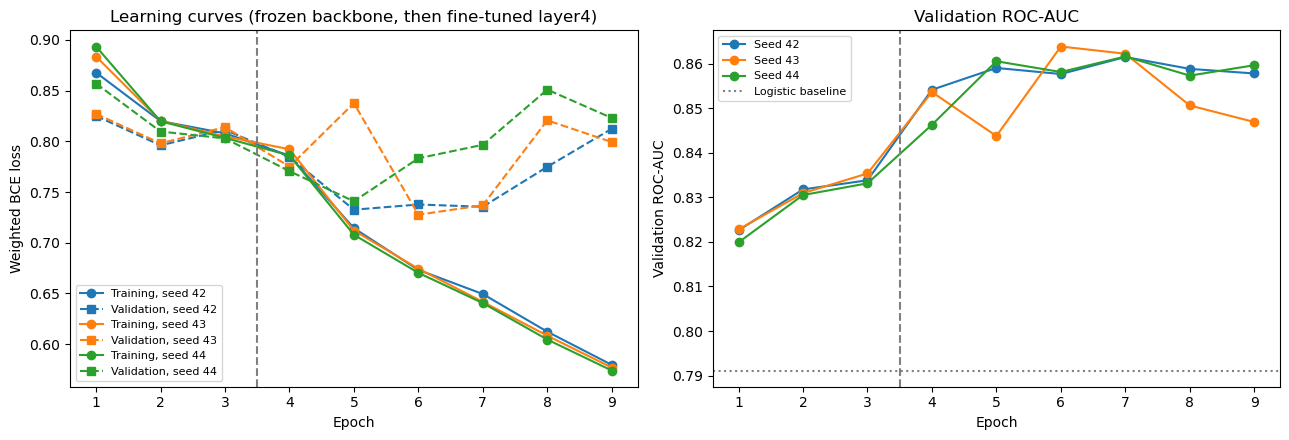

In [70]:
colors = ["tab:blue", "tab:orange", "tab:green"]
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for seed, color in zip(SEEDS, colors):
    history = histories[(histories["loss"] == "weighted") & (histories["seed"] == seed)]
    axes[0].plot(history["epoch"], history["train_loss"], "o-", color=color, label=f"Training, seed {seed}")
    axes[0].plot(history["epoch"], history["val_loss"], "s--", color=color, label=f"Validation, seed {seed}")
    axes[1].plot(history["epoch"], history["val_auc"], "o-", color=color, label=f"Seed {seed}")
axes[1].axhline(best["val_roc_auc"], color="gray", linestyle=":", label="Logistic baseline")
for ax in axes:
    ax.axvline(3.5, color="gray", linestyle="--")
    ax.set_xlabel("Epoch")
    ax.legend(fontsize=8)
axes[0].set_ylabel("Weighted BCE loss")
axes[0].set_title("Learning curves (frozen backbone, then fine-tuned layer4)")
axes[1].set_ylabel("Validation ROC-AUC")
axes[1].set_title("Validation ROC-AUC")
plt.tight_layout()
plt.show()

In [71]:
def load_resnet(loss_name, seed):
    model = build_resnet(pretrained=False)
    model.load_state_dict(torch.load(MODEL_DIR / f"resnet18_{loss_name}_seed{seed}.pt", map_location="cpu"))
    return model.to(DEVICE)


test_table = splits[splits["split"] == "test"]
test_dataset = ChestXrayDataset(test_table, cache)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False, num_workers=0)

val_predictions = {}
test_predictions = {}
for loss_name in ["weighted", "plain"]:
    for seed in SEEDS:
        model = load_resnet(loss_name, seed)
        _, val_predictions[(loss_name, seed)], _ = predict(model, validation_loader)
        if loss_name == "weighted":
            _, test_predictions[(loss_name, seed)], _ = predict(model, test_loader)

rows = []
for seed in SEEDS:
    history = histories[(histories["loss"] == "weighted") & (histories["seed"] == seed)]
    rows.append({
        "seed": seed,
        "Frozen val ROC-AUC": history[history["stage"] == "feature_extractor"]["val_auc"].max(),
        "Fine-tuned val ROC-AUC": roc_auc_score(y_val, val_predictions[("weighted", seed)]),
        "Best epoch": history["best_epoch"].iloc[0],
        "Fine-tuned test ROC-AUC": roc_auc_score(y_test, test_predictions[("weighted", seed)]),
    })
seed_table = pd.DataFrame(rows).set_index("seed")
display(seed_table.round(4))
display(seed_table.agg(["mean", "std"]).round(4))

,Frozen val ROC-AUC,Fine-tuned val ROC-AUC,Best epoch,Fine-tuned test ROC-AUC
seed,,,,
42,0.8338,0.8615,7,0.8644
43,0.8353,0.8638,6,0.8682
44,0.8331,0.8616,7,0.8728


,Frozen val ROC-AUC,Fine-tuned val ROC-AUC,Best epoch,Fine-tuned test ROC-AUC
mean,0.8341,0.8623,6.6667,0.8685
std,0.0011,0.0013,0.5774,0.0042


In [72]:
rows = []
for seed in SEEDS:
    model, column_index, _, _ = train_logistic(best_columns, best["weight_decay"], pos_weight=POS_WEIGHT, seed=seed)
    rows.append({
        "seed": seed,
        "Val ROC-AUC": roc_auc_score(y_val, predict_logistic(model, X_val[:, column_index])),
        "Test ROC-AUC": roc_auc_score(y_test, predict_logistic(model, X_test[:, column_index])),
    })
baseline_seed_table = pd.DataFrame(rows).set_index("seed")
display(baseline_seed_table.agg(["mean", "std"]).round(4))

cnn_mean = seed_table["Fine-tuned test ROC-AUC"].mean()
cnn_std = seed_table["Fine-tuned test ROC-AUC"].std()
gap = cnn_mean - baseline_seed_table["Test ROC-AUC"].mean()
print(f"Test ROC-AUC: CNN {cnn_mean:.4f} +/- {cnn_std:.4f}")
print(f"Gap to baseline: {gap:.4f}, which is {gap / cnn_std:.1f} times the CNN seed standard deviation")

,Val ROC-AUC,Test ROC-AUC
mean,0.7911,0.8036
std,0.0002,0.0008


Test ROC-AUC: CNN 0.8685 +/- 0.0042
Gap to baseline: 0.0649, which is 15.3 times the CNN seed standard deviation


In [73]:
rows = []
for loss_name in ["plain", "weighted"]:
    for seed in SEEDS:
        p_val = val_predictions[(loss_name, seed)]
        at_05 = metric_row(loss_name, y_val, p_val)
        tuned = metric_row(loss_name, y_val, p_val, youden_threshold(y_val, p_val))
        rows.append({
            "loss": loss_name,
            "seed": seed,
            "ROC-AUC": at_05["ROC-AUC"],
            "Average precision": at_05["Average precision"],
            "Sensitivity @0.5": at_05["Sensitivity"],
            "Specificity @0.5": at_05["Specificity"],
            "Balanced accuracy @0.5": at_05["Balanced accuracy"],
            "Balanced accuracy @tuned": tuned["Balanced accuracy"],
            "Mean probability": p_val.mean(),
        })
loss_comparison = pd.DataFrame(rows)
loss_comparison.drop(columns="seed").groupby("loss").agg(["mean", "std"]).round(3).T

loss                           plain  weighted
ROC-AUC                  mean  0.861     0.862
                         std   0.002     0.001
Average precision        mean  0.631     0.629
                         std   0.004     0.005
Sensitivity @0.5         mean  0.527     0.806
                         std   0.027     0.035
Specificity @0.5         mean  0.911     0.763
                         std   0.009     0.042
Balanced accuracy @0.5   mean  0.719     0.785
                         std   0.009     0.004
Balanced accuracy @tuned mean  0.787     0.788
                         std   0.007     0.006
Mean probability         mean  0.225     0.376
                         std   0.025     0.041

## Part F

In [74]:
p_cnn_val = val_predictions[("weighted", 42)]
p_cnn_test = test_predictions[("weighted", 42)]

validation_thresholds = threshold_table(y_val, p_cnn_val)
balanced_threshold = youden_threshold(y_val, p_cnn_val)

screening_candidates = validation_thresholds[validation_thresholds["sensitivity"] >= 0.90]
screening_threshold = screening_candidates["threshold"].max()

specificity_candidates = validation_thresholds[validation_thresholds["specificity"] >= 0.95]
high_specificity_threshold = specificity_candidates["threshold"].min()

print("Balanced threshold:", round(balanced_threshold, 2))
print("Screening threshold:", round(screening_threshold, 2))
print("High-specificity threshold:", round(high_specificity_threshold, 2))

thresholds = {
    "Balanced": balanced_threshold,
    "Screening": screening_threshold,
    "High specificity": high_specificity_threshold,
}
rows = []
for name, threshold in thresholds.items():
    rows.append(metric_row(f"{name} (val)", y_val, p_cnn_val, threshold))
    rows.append(metric_row(f"{name} (test)", y_test, p_cnn_test, threshold))
threshold_results = pd.DataFrame(rows).set_index("Model")
threshold_results[["Sensitivity", "Specificity", "Precision", "F1", "Accuracy"]].round(3)

Balanced threshold: 0.53
Screening threshold: 0.37
High-specificity threshold: 0.89


,Sensitivity,Specificity,Precision,F1,Accuracy
Model,,,,,
Balanced (val),0.821,0.742,0.478,0.605,0.760
Balanced (test),0.811,0.752,0.484,0.606,0.765
Screening (val),0.902,0.629,0.412,0.566,0.690
Screening (test),0.891,0.631,0.409,0.561,0.689
High specificity (val),0.361,0.954,0.694,0.475,0.821
High specificity (test),0.438,0.963,0.773,0.559,0.846


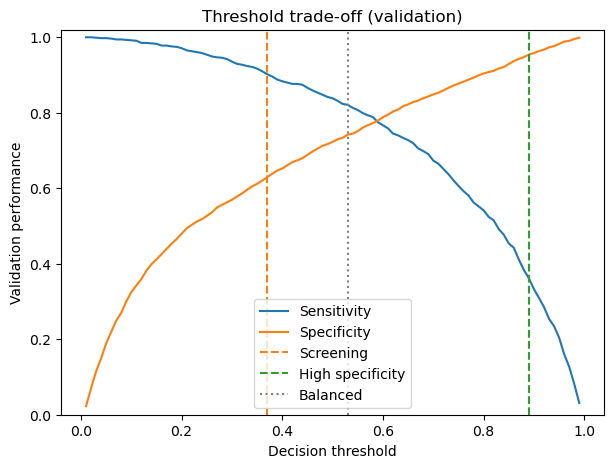

In [75]:
plt.figure(figsize=(7, 5))
plt.plot(validation_thresholds["threshold"], validation_thresholds["sensitivity"], label="Sensitivity")
plt.plot(validation_thresholds["threshold"], validation_thresholds["specificity"], label="Specificity")
plt.axvline(screening_threshold, color="tab:orange", linestyle="--", label="Screening")
plt.axvline(high_specificity_threshold, color="tab:green", linestyle="--", label="High specificity")
plt.axvline(balanced_threshold, color="gray", linestyle=":", label="Balanced")
plt.xlabel("Decision threshold")
plt.ylabel("Validation performance")
plt.ylim(0, 1.02)
plt.legend()
plt.title("Threshold trade-off (validation)")
plt.show()

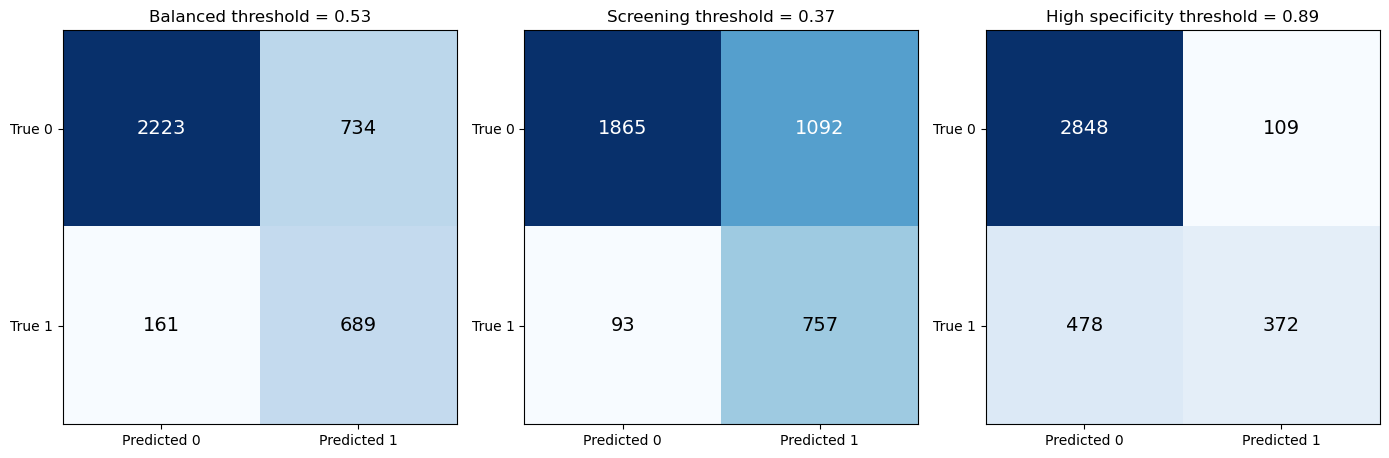

In [76]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
for ax, (name, threshold) in zip(axes, thresholds.items()):
    y_pred = (p_cnn_test >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred, labels=[0, 1]).ravel()
    confusion = np.array([[tn, fp], [fn, tp]])
    ax.imshow(confusion, cmap="Blues")
    for (row, column), value in np.ndenumerate(confusion):
        text_color = "white" if value > confusion.max() / 2 else "black"
        ax.text(column, row, value, ha="center", va="center", fontsize=14, color=text_color)
    ax.set_xticks([0, 1], ["Predicted 0", "Predicted 1"])
    ax.set_yticks([0, 1], ["True 0", "True 1"])
    ax.set_title(f"{name} threshold = {threshold:.2f}")
plt.tight_layout()
plt.show()

In [77]:
comparison = pd.DataFrame([
    metric_row("Majority class", y_test, np.full(len(y_test), train_prevalence)),
    metric_row("Logistic baseline (balanced)", y_test, p_logistic_test, logistic_threshold),
    metric_row("CNN (balanced)", y_test, p_cnn_test, balanced_threshold),
    metric_row("CNN (screening)", y_test, p_cnn_test, screening_threshold),
    metric_row("CNN (high specificity)", y_test, p_cnn_test, high_specificity_threshold),
]).set_index("Model")
comparison.round(3)

,ROC-AUC,Average precision,Accuracy,Balanced accuracy,Sensitivity,Specificity,Precision,F1
Model,,,,,,,,
Majority class,0.500,0.223,0.777,0.500,0.000,1.000,0.000,0.000
Logistic baseline (balanced),0.804,0.544,0.743,0.724,0.689,0.758,0.450,0.545
CNN (balanced),0.864,0.684,0.765,0.781,0.811,0.752,0.484,0.606
CNN (screening),0.864,0.684,0.689,0.761,0.891,0.631,0.409,0.561
CNN (high specificity),0.864,0.684,0.846,0.700,0.438,0.963,0.773,0.559


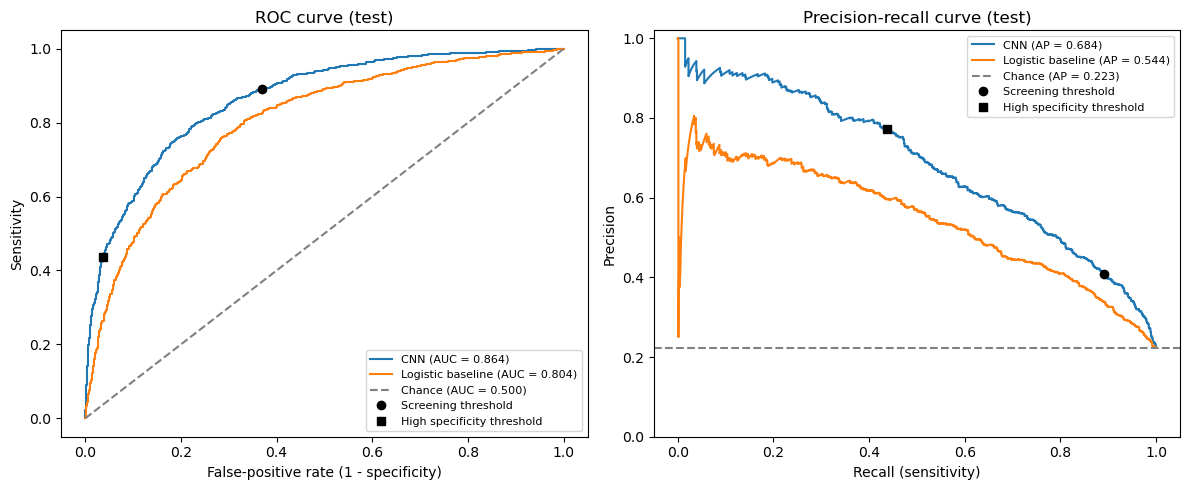

In [78]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for name, p_test in [("CNN", p_cnn_test), ("Logistic baseline", p_logistic_test)]:
    fpr, tpr, _ = roc_curve(y_test, p_test)
    precision, recall, _ = precision_recall_curve(y_test, p_test)
    axes[0].plot(fpr, tpr, label=f"{name} (AUC = {roc_auc_score(y_test, p_test):.3f})")
    axes[1].plot(recall, precision, label=f"{name} (AP = {average_precision_score(y_test, p_test):.3f})")

axes[0].plot([0, 1], [0, 1], "--", color="gray", label="Chance (AUC = 0.500)")
axes[1].axhline(y_test.mean(), linestyle="--", color="gray", label=f"Chance (AP = {y_test.mean():.3f})")

for name, threshold, marker in [("Screening", screening_threshold, "o"), ("High specificity", high_specificity_threshold, "s")]:
    row = metric_row(name, y_test, p_cnn_test, threshold)
    axes[0].plot(1 - row["Specificity"], row["Sensitivity"], marker, color="black", label=f"{name} threshold")
    axes[1].plot(row["Sensitivity"], row["Precision"], marker, color="black", label=f"{name} threshold")

axes[0].set_xlabel("False-positive rate (1 - specificity)")
axes[0].set_ylabel("Sensitivity")
axes[0].set_title("ROC curve (test)")
axes[1].set_xlabel("Recall (sensitivity)")
axes[1].set_ylabel("Precision")
axes[1].set_ylim(0, 1.02)
axes[1].set_title("Precision-recall curve (test)")
for ax in axes:
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

CNN, weighted BCE | mean probability: 0.421 | ROC-AUC: 0.864
CNN, plain BCE | mean probability: 0.259 | ROC-AUC: 0.863


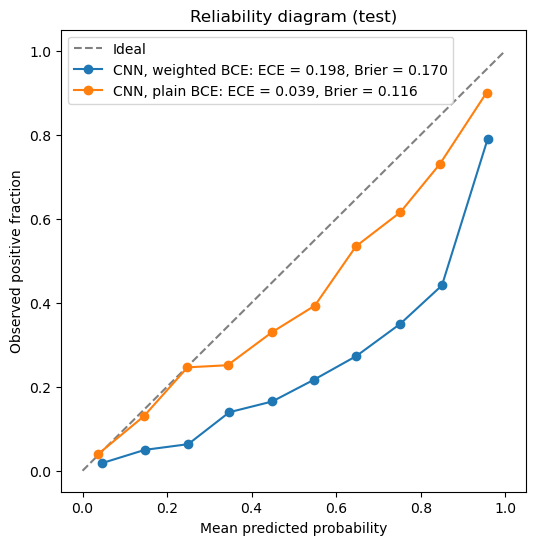

In [89]:
def reliability_points(y_true, y_prob, n_bins=10):
    edges = np.linspace(0, 1, n_bins + 1)
    rows = []
    for left, right in zip(edges[:-1], edges[1:]):
        include = (y_prob >= left) & (y_prob < right if right < 1 else y_prob <= right)
        if include.any():
            rows.append({
                "mean_probability": y_prob[include].mean(),
                "observed_fraction": y_true[include].mean(),
                "count": int(include.sum()),
            })
    return pd.DataFrame(rows)


plain_cnn = load_resnet("plain", 42)
_, p_cnn_plain_test, _ = predict(plain_cnn, test_loader)

plt.figure(figsize=(6, 6))
plt.plot([0, 1], [0, 1], "--", color="gray", label="Ideal")
for name, p_test in [("CNN, weighted BCE", p_cnn_test), ("CNN, plain BCE", p_cnn_plain_test)]:
    reliability = reliability_points(y_test, p_test)
    gaps = (reliability["mean_probability"] - reliability["observed_fraction"]).abs()
    ece = (reliability["count"] * gaps).sum() / len(y_test)
    brier = np.mean((p_test - y_test) ** 2)
    plt.plot(reliability["mean_probability"], reliability["observed_fraction"], "o-",
             label=f"{name}: ECE = {ece:.3f}, Brier = {brier:.3f}")
    print(name, "| mean probability:", round(p_test.mean(), 3), "| ROC-AUC:", round(roc_auc_score(y_test, p_test), 3))
plt.xlabel("Mean predicted probability")
plt.ylabel("Observed positive fraction")
plt.title("Reliability diagram (test)")
plt.legend()
plt.show()

## Part G

outcome
TN    2223
FP     734
TP     689
FN     161
Name: count, dtype: int64


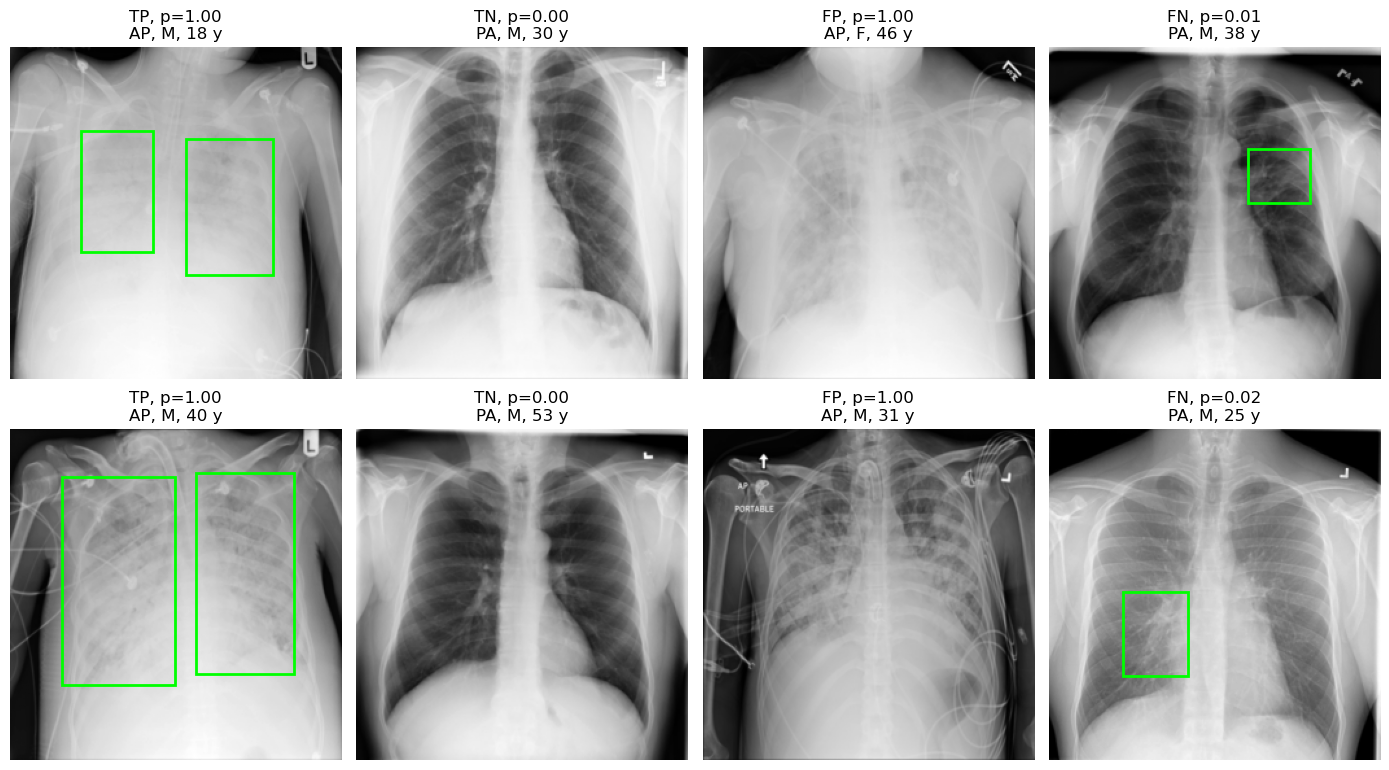

In [91]:
test_results = test_table.reset_index(drop=True)
test_results = test_results.merge(images[["image_id", "sex", "age"]], on="image_id", how="left")
test_results["probability"] = p_cnn_test
test_results["prediction"] = (p_cnn_test >= balanced_threshold).astype(int)
test_results["outcome"] = np.select(
    [
        (test_results["target"] == 1) & (test_results["prediction"] == 1),
        (test_results["target"] == 0) & (test_results["prediction"] == 0),
        (test_results["target"] == 0) & (test_results["prediction"] == 1),
        (test_results["target"] == 1) & (test_results["prediction"] == 0),
    ],
    ["TP", "TN", "FP", "FN"],
)
print(test_results["outcome"].value_counts())

examples = []
for outcome, ascending in [("TP", False), ("TN", True), ("FP", False), ("FN", True)]:
    cases = test_results[test_results["outcome"] == outcome].sort_values("probability", ascending=ascending)
    cases = cases.drop_duplicates("nih_patient_id")
    examples.append(cases.head(2))
examples = pd.concat(examples)

scale = IMG_SIZE / 1024


def show_case(ax, row, cam=None):
    ax.imshow(cache[row["cache_index"]], cmap="gray")
    if cam is not None:
        ax.imshow(cam, cmap="jet", alpha=0.4)
    for _, box in boxes[boxes["patientId"] == row["image_id"]].iterrows():
        ax.add_patch(Rectangle((box["x"] * scale, box["y"] * scale), box["width"] * scale, box["height"] * scale,
                               fill=False, edgecolor="lime", linewidth=2))
    ax.set_title(f"{row['outcome']}, p={row['probability']:.2f}\n{row['view']}, {row['sex']}, {row['age']} y")
    ax.axis("off")


fig, axes = plt.subplots(2, 4, figsize=(14, 8))
for ax, (_, row) in zip(axes.T.flat, examples.iterrows()):
    show_case(ax, row)
plt.tight_layout()
plt.show()

In [92]:
def patient_bootstrap_auc(table, n_boot=1000):
    rng = np.random.default_rng(SEED)
    groups = [group for _, group in table.groupby("nih_patient_id")]
    targets = [group["target"].to_numpy() for group in groups]
    probabilities = [group["probability"].to_numpy() for group in groups]
    aucs = []
    for _ in range(n_boot):
        chosen = rng.integers(0, len(groups), len(groups))
        sample_targets = np.concatenate([targets[i] for i in chosen])
        sample_probabilities = np.concatenate([probabilities[i] for i in chosen])
        if 0 < sample_targets.sum() < len(sample_targets):
            aucs.append(roc_auc_score(sample_targets, sample_probabilities))
    return np.percentile(aucs, [2.5, 97.5])


valid_age = test_results["age"].where(test_results["age"] <= 100)
test_results["age_group"] = pd.cut(valid_age, [0, 17, 64, 200], labels=["<18", "18-64", "65+"])

subgroup_values = {"view": ["AP", "PA"], "sex": ["F", "M"], "age_group": ["<18", "18-64", "65+"]}
rows = []
for column, values in subgroup_values.items():
    for value in values:
        group = test_results[test_results[column] == value]
        metrics = metric_row(value, group["target"], group["probability"], balanced_threshold)
        low, high = patient_bootstrap_auc(group)
        rows.append({
            "Subgroup": f"{column} = {value}",
            "Images": len(group),
            "Patients": group["nih_patient_id"].nunique(),
            "Positives": group["target"].sum(),
            "Prevalence": group["target"].mean(),
            "ROC-AUC": metrics["ROC-AUC"],
            "95% CI": f"{low:.3f}-{high:.3f}",
            "Sensitivity": metrics["Sensitivity"],
            "Specificity": metrics["Specificity"],
        })
subgroups = pd.DataFrame(rows).set_index("Subgroup")
subgroups.round(3)

,Images,Patients,Positives,Prevalence,ROC-AUC,95% CI,Sensitivity,Specificity
Subgroup,,,,,,,,
view = AP,1782,632,672,0.377,0.830,0.799-0.858,0.879,0.567
view = PA,2025,1364,178,0.088,0.803,0.762-0.838,0.551,0.863
sex = F,1667,754,341,0.205,0.852,0.817-0.880,0.809,0.720
sex = M,2140,922,509,0.238,0.875,0.848-0.899,0.811,0.777
age_group = <18,160,79,38,0.238,0.887,0.793-0.938,0.842,0.746
age_group = 18-64,3101,1361,695,0.224,0.877,0.854-0.898,0.823,0.760
age_group = 65+,546,255,117,0.214,0.778,0.723-0.827,0.726,0.706


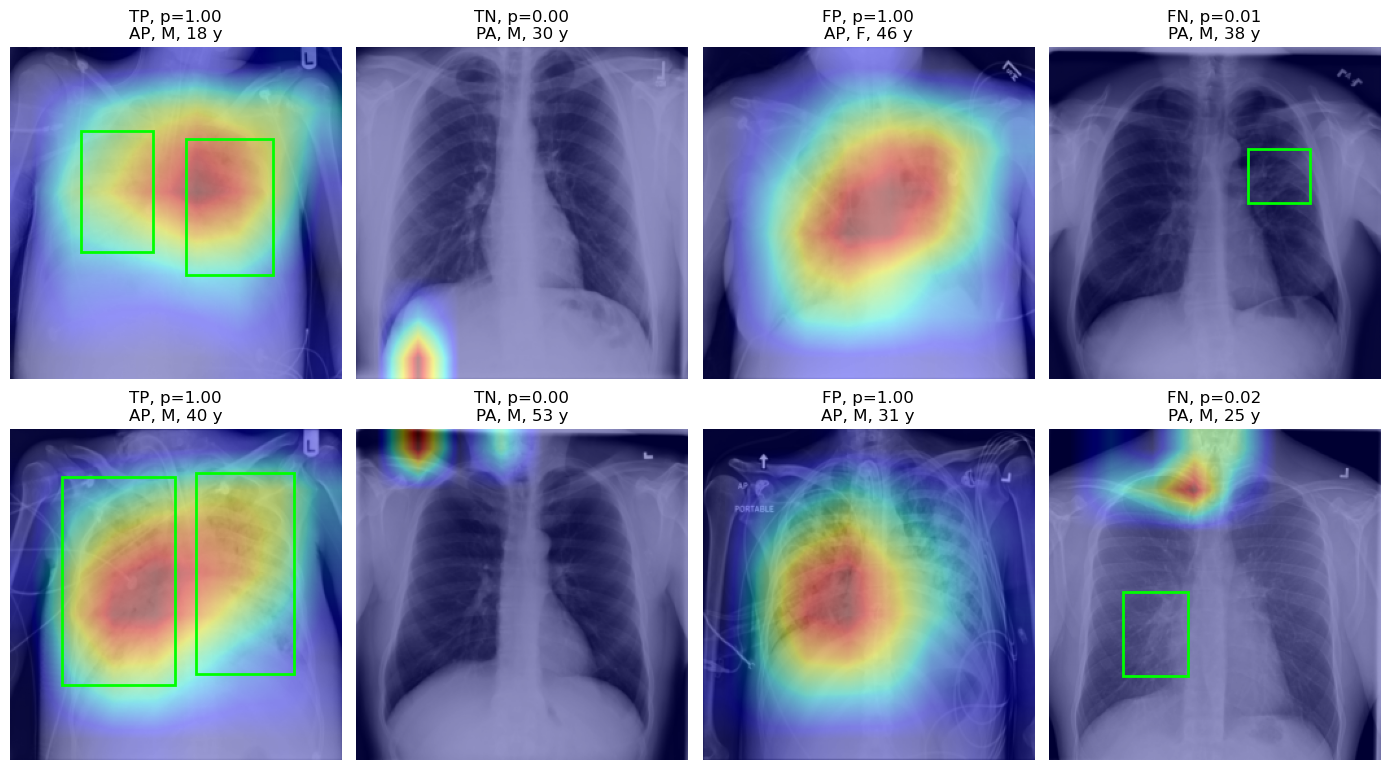

In [93]:
def grad_cam(model, image_tensor, target_layer):
    activations, gradients = {}, {}

    def save_activation(_, __, output):
        activations["value"] = output

    def save_gradient(_, grad_input, grad_output):
        gradients["value"] = grad_output[0]

    forward_handle = target_layer.register_forward_hook(save_activation)
    backward_handle = target_layer.register_full_backward_hook(save_gradient)

    model.eval()
    x = image_tensor.unsqueeze(0).to(DEVICE).requires_grad_(True)
    model.zero_grad()
    logit = model(x).reshape(-1)[0]
    logit.backward()

    weights = gradients["value"].mean(dim=(2, 3), keepdim=True)
    cam = torch.relu((weights * activations["value"]).sum(dim=1, keepdim=True))
    cam = F.interpolate(cam, size=image_tensor.shape[-2:], mode="bilinear", align_corners=False)
    cam = cam[0, 0].detach().cpu().numpy()
    cam = (cam - cam.min()) / max(float(cam.max() - cam.min()), 1e-6)

    forward_handle.remove()
    backward_handle.remove()
    return cam, float(torch.sigmoid(logit).detach().cpu())


cnn_model = load_resnet("weighted", 42)
target_layer = cnn_model.layer4[-1]

fig, axes = plt.subplots(2, 4, figsize=(14, 8))
for ax, (index, row) in zip(axes.T.flat, examples.iterrows()):
    image_tensor, _, _ = test_dataset[index]
    cam, probability = grad_cam(cnn_model, image_tensor, target_layer)
    show_case(ax, row, cam)
plt.tight_layout()
plt.show()

In [94]:
border = np.ones((IMG_SIZE, IMG_SIZE), dtype=bool)
border[26:-26, 26:-26] = False

rows = []
for index, row in test_results.iterrows():
    image_tensor, _, _ = test_dataset[index]
    cam, _ = grad_cam(cnn_model, image_tensor, target_layer)
    box_mask = np.zeros((IMG_SIZE, IMG_SIZE), dtype=bool)
    for _, box in boxes[boxes["patientId"] == row["image_id"]].iterrows():
        x0, y0 = int(box["x"] * scale), int(box["y"] * scale)
        box_mask[y0:y0 + int(box["height"] * scale) + 1, x0:x0 + int(box["width"] * scale) + 1] = True
    empty = cam.sum() == 0
    peak = np.unravel_index(cam.argmax(), cam.shape)
    rows.append({
        "outcome": row["outcome"],
        "target": row["target"],
        "empty_map": empty,
        "border_share": np.nan if empty else cam[border].sum() / cam.sum(),
        "peak_in_box": (not empty) and box_mask[peak],
        "cam_share_in_boxes": np.nan if empty else cam[box_mask].sum() / cam.sum(),
        "box_area": box_mask.mean(),
    })
cam_table = pd.DataFrame(rows)

positive_cams = cam_table[cam_table["target"] == 1]
print("Positives: CAM peak inside a radiologist box:", round(positive_cams["peak_in_box"].mean(), 3))
print("Positives: box share of image area (chance level):", round(positive_cams["box_area"].mean(), 3))
print("Positives: share of CAM inside boxes:", round(positive_cams["cam_share_in_boxes"].mean(), 3))
print("All test images: share of CAM in the outer 10% border (area = 36%):", round(cam_table["border_share"].mean(), 3))
cam_table.groupby("outcome")[["border_share", "empty_map", "peak_in_box"]].mean().round(3)

Positives: CAM peak inside a radiologist box: 0.412
Positives: box share of image area (chance level): 0.127
Positives: share of CAM inside boxes: 0.251
All test images: share of CAM in the outer 10% border (area = 36%): 0.232


,border_share,empty_map,peak_in_box
outcome,,,
FN,0.202,0.006,0.043
FP,0.126,0.000,0.000
TN,0.308,0.014,0.000
TP,0.108,0.000,0.498


## Bonus 1 

In [84]:
positive_rows = np.where(y_test == 1)[0]
negative_rows = np.where(y_test == 0)[0]
n_keep_positive = round(0.10 * len(negative_rows) / 0.90)
n_keep_negative = round(len(positive_rows) * 0.60 / 0.40)

rng = np.random.default_rng(SEED)
low_prevalence = np.concatenate([rng.choice(positive_rows, n_keep_positive, replace=False), negative_rows])
high_prevalence = np.concatenate([positive_rows, rng.choice(negative_rows, n_keep_negative, replace=False)])

test_sets = {
    "Original test": np.arange(len(y_test)),
    "~10% prevalence": low_prevalence,
    "~40% prevalence": high_prevalence,
}
rows = []
for name, selected in test_sets.items():
    metrics = metric_row(name, y_test[selected], p_cnn_test[selected], screening_threshold)
    rows.append({
        "Test set": name,
        "Images": len(selected),
        "Positives": y_test[selected].sum(),
        "Prevalence": y_test[selected].mean(),
        "Sensitivity": metrics["Sensitivity"],
        "Specificity": metrics["Specificity"],
        "Precision (PPV)": metrics["Precision"],
        "F1": metrics["F1"],
        "ROC-AUC": metrics["ROC-AUC"],
    })
shift_table = pd.DataFrame(rows).set_index("Test set")
shift_table.round(3)

,Images,Positives,Prevalence,Sensitivity,Specificity,Precision (PPV),F1,ROC-AUC
Test set,,,,,,,,
Original test,3807,850,0.223,0.891,0.631,0.409,0.561,0.864
~10% prevalence,3286,329,0.100,0.897,0.631,0.213,0.344,0.872
~40% prevalence,2125,850,0.400,0.891,0.627,0.614,0.727,0.865


In [85]:
rng = np.random.default_rng(SEED + 1)
rows = []
for repeat in range(200):
    low = np.concatenate([rng.choice(positive_rows, n_keep_positive, replace=False), negative_rows])
    high = np.concatenate([positive_rows, rng.choice(negative_rows, n_keep_negative, replace=False)])
    for name, selected in [("~10% prevalence", low), ("~40% prevalence", high)]:
        rows.append(metric_row(name, y_test[selected], p_cnn_test[selected], screening_threshold))
repeats = pd.DataFrame(rows)
repeats.groupby("Model")[["Sensitivity", "Specificity", "Precision", "F1", "ROC-AUC"]].agg(["mean", "std"]).round(3)

Sensitivity        Specificity       Precision            F1  \
                       mean    std        mean   std      mean    std   mean   
Model                                                                          
~10% prevalence       0.890  0.013       0.631  0.00     0.211  0.002  0.342   
~40% prevalence       0.891  0.000       0.630  0.01     0.616  0.007  0.729   

                       ROC-AUC         
                   std    mean    std  
Model                                  
~10% prevalence  0.004   0.864  0.008  
~40% prevalence  0.005   0.864  0.004

In [86]:
sensitivity = shift_table.loc["Original test", "Sensitivity"]
specificity = shift_table.loc["Original test", "Specificity"]
for prevalence in [0.05, 0.10, y_test.mean(), 0.40]:
    ppv = sensitivity * prevalence / (sensitivity * prevalence + (1 - specificity) * (1 - prevalence))
    print(f"Prevalence {prevalence:.1%}: PPV = {ppv:.3f}, false alarms per true case = {(1 - ppv) / ppv:.1f}")

Prevalence 5.0%: PPV = 0.113, false alarms per true case = 7.9
Prevalence 10.0%: PPV = 0.211, false alarms per true case = 3.7
Prevalence 22.3%: PPV = 0.409, false alarms per true case = 1.4
Prevalence 40.0%: PPV = 0.617, false alarms per true case = 0.6
